# Day 09 — Data Preprocessing & Feature Scaling

**Coding + Coding Explanation Notebook**

## 1. Import Libraries

Pandas handles data, NumPy creates missing values, Matplotlib visualizes data, and Scikit-Learn provides preprocessing tools.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## 2. Create a Messy Dataset

This dataset intentionally contains missing values, a duplicate row, categorical data, and a potential outlier.

In [2]:
data = {
    "Age": [21, 24, np.nan, 29, 35, 40, 150, 24],
    "Salary": [25000, 30000, 35000, np.nan, 45000, 50000, 60000, 30000],
    "City": ["Hyderabad", "Chennai", "Bangalore", "Hyderabad",
             "Mumbai", "Chennai", "Hyderabad", "Chennai"],
    "Experience": [1, 2, 3, 5, 8, 12, 15, 2]
}

df = pd.DataFrame(data)
print(df)


     Age   Salary       City  Experience
0   21.0  25000.0  Hyderabad           1
1   24.0  30000.0    Chennai           2
2    NaN  35000.0  Bangalore           3
3   29.0      NaN  Hyderabad           5
4   35.0  45000.0     Mumbai           8
5   40.0  50000.0    Chennai          12
6  150.0  60000.0  Hyderabad          15
7   24.0  30000.0    Chennai           2


## 3. Inspect the Dataset

`shape`, `info()` and `describe()` help us understand the dataset before preprocessing.

In [3]:
print("Shape:", df.shape)
print("\nInformation:")
df.info()
print("\nStatistics:")
print(df.describe())


Shape: (8, 4)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         7 non-null      float64
 1   Salary      7 non-null      float64
 2   City        8 non-null      object 
 3   Experience  8 non-null      int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 388.0+ bytes

Statistics:
              Age        Salary  Experience
count    7.000000      7.000000    8.000000
mean    46.142857  39285.714286    6.000000
std     46.286890  12724.180206    5.182388
min     21.000000  25000.000000    1.000000
25%     24.000000  30000.000000    2.000000
50%     29.000000  35000.000000    4.000000
75%     37.500000  47500.000000    9.000000
max    150.000000  60000.000000   15.000000


## 4. Check Missing Values

`isnull().sum()` counts missing values in every column.

In [4]:
print(df.isnull().sum())


Age           1
Salary        1
City          0
Experience    0
dtype: int64


## 5. Check and Remove Duplicates

We first count duplicates, inspect them, and then remove complete duplicate rows.

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("\nDuplicate rows:")
print(df[df.duplicated()])

df = df.drop_duplicates().reset_index(drop=True)

print("\nAfter removing duplicates:")
print(df)


Duplicate rows: 1

Duplicate rows:
    Age   Salary     City  Experience
7  24.0  30000.0  Chennai           2

After removing duplicates:
     Age   Salary       City  Experience
0   21.0  25000.0  Hyderabad           1
1   24.0  30000.0    Chennai           2
2    NaN  35000.0  Bangalore           3
3   29.0      NaN  Hyderabad           5
4   35.0  45000.0     Mumbai           8
5   40.0  50000.0    Chennai          12
6  150.0  60000.0  Hyderabad          15


## 6. Handle Missing Numerical Values

For this example, median imputation is used because the median is less affected by extreme values than the mean.

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

print(df)
print("\nMissing values:")
print(df.isnull().sum())


     Age   Salary       City  Experience
0   21.0  25000.0  Hyderabad           1
1   24.0  30000.0    Chennai           2
2   32.0  35000.0  Bangalore           3
3   29.0  40000.0  Hyderabad           5
4   35.0  45000.0     Mumbai           8
5   40.0  50000.0    Chennai          12
6  150.0  60000.0  Hyderabad          15

Missing values:
Age           0
Salary        0
City          0
Experience    0
dtype: int64


## 7. Detect Outliers with IQR

`IQR = Q3 - Q1`. Potential outliers are values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [7]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print("\nPotential outliers:")
print(outliers)


Q1: 26.5
Q3: 37.5
IQR: 11.0
Lower bound: 10.0
Upper bound: 54.0

Potential outliers:
     Age   Salary       City  Experience
6  150.0  60000.0  Hyderabad          15


## 8. Visualize Outliers

A box plot gives a quick visual indication of unusually high or low observations.

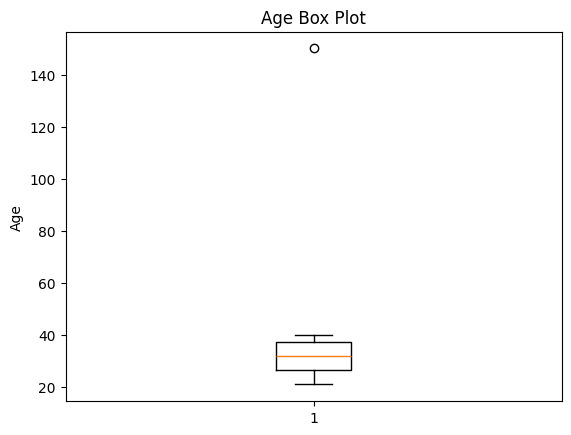

In [8]:
plt.boxplot(df["Age"])
plt.ylabel("Age")
plt.title("Age Box Plot")
plt.show()


## 9. Handle an Invalid Outlier

In this classroom dataset, age 150 is clearly invalid. We use domain knowledge rather than automatically deleting every statistical outlier.

In [9]:
valid_age_median = df.loc[df["Age"] <= 100, "Age"].median()
df.loc[df["Age"] > 100, "Age"] = valid_age_median

print(df)


    Age   Salary       City  Experience
0  21.0  25000.0  Hyderabad           1
1  24.0  30000.0    Chennai           2
2  32.0  35000.0  Bangalore           3
3  29.0  40000.0  Hyderabad           5
4  35.0  45000.0     Mumbai           8
5  40.0  50000.0    Chennai          12
6  30.5  60000.0  Hyderabad          15


## 10. One-Hot Encoding

One-hot encoding creates binary columns for nominal categories such as City.

In [10]:
encoded_df = pd.get_dummies(
    df,
    columns=["City"],
    dtype=int
)

print(encoded_df)


    Age   Salary  Experience  City_Bangalore  City_Chennai  City_Hyderabad  \
0  21.0  25000.0           1               0             0               1   
1  24.0  30000.0           2               0             1               0   
2  32.0  35000.0           3               1             0               0   
3  29.0  40000.0           5               0             0               1   
4  35.0  45000.0           8               0             0               0   
5  40.0  50000.0          12               0             1               0   
6  30.5  60000.0          15               0             0               1   

   City_Mumbai  
0            0  
1            0  
2            0  
3            0  
4            1  
5            0  
6            0  


## 11. Label Encoding

Label encoding assigns numbers to categories. It should be used carefully for nominal data because the numbers may imply an artificial order.

In [11]:
label_encoder = LabelEncoder()

city_encoded = label_encoder.fit_transform(df["City"])

print("Original:")
print(df["City"].values)

print("\nEncoded:")
print(city_encoded)

print("\nClasses:")
print(label_encoder.classes_)


Original:
['Hyderabad' 'Chennai' 'Bangalore' 'Hyderabad' 'Mumbai' 'Chennai'
 'Hyderabad']

Encoded:
[2 1 0 2 3 1 2]

Classes:
['Bangalore' 'Chennai' 'Hyderabad' 'Mumbai']


## 12. Standardization

Standardization uses `z = (x - mean) / standard_deviation` and generally produces features centered around 0.

In [12]:
numeric_features = ["Age", "Salary", "Experience"]

standard_scaler = StandardScaler()

X_standardized = standard_scaler.fit_transform(
    df[numeric_features]
)

standardized_df = pd.DataFrame(
    X_standardized,
    columns=numeric_features
)

print(standardized_df)


        Age    Salary  Experience
0 -1.551404 -1.408406   -1.131505
1 -1.046296 -0.960277   -0.928414
2  0.300660 -0.512148   -0.725324
3 -0.204449 -0.064018   -0.319142
4  0.805768  0.384111    0.290129
5  1.647616  0.832240    1.102492
6  0.048106  1.728498    1.711764


## 13. Check Standardized Statistics

After standardization, each feature should have a mean close to 0 and standard deviation close to 1.

In [13]:
print("Means:")
print(standardized_df.mean())

print("\nStandard deviations:")
print(standardized_df.std())


Means:
Age          -1.893327e-16
Salary       -2.537653e-16
Experience    9.516197e-17
dtype: float64

Standard deviations:
Age           1.080123
Salary        1.080123
Experience    1.080123
dtype: float64


## 14. Normalization with MinMaxScaler

Min-Max scaling commonly maps values to the range 0 to 1.

In [14]:
minmax_scaler = MinMaxScaler()

X_normalized = minmax_scaler.fit_transform(
    df[numeric_features]
)

normalized_df = pd.DataFrame(
    X_normalized,
    columns=numeric_features
)

print(normalized_df)


        Age    Salary  Experience
0  0.000000  0.000000    0.000000
1  0.157895  0.142857    0.071429
2  0.578947  0.285714    0.142857
3  0.421053  0.428571    0.285714
4  0.736842  0.571429    0.500000
5  1.000000  0.714286    0.785714
6  0.500000  1.000000    1.000000


## 15. Compare Scaling Methods

In [15]:
comparison = pd.DataFrame({
    "Age": df["Age"],
    "Standardized_Age": standardized_df["Age"],
    "Normalized_Age": normalized_df["Age"]
})

print(comparison)


    Age  Standardized_Age  Normalized_Age
0  21.0         -1.551404        0.000000
1  24.0         -1.046296        0.157895
2  32.0          0.300660        0.578947
3  29.0         -0.204449        0.421053
4  35.0          0.805768        0.736842
5  40.0          1.647616        1.000000
6  30.5          0.048106        0.500000


## 16. Train/Test Split

We split before learning preprocessing parameters so that the test set remains unseen.

In [16]:
X = df[["Age", "Salary", "Experience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (5, 3)
Testing shape: (2, 3)


## 17. Correct Scaling Workflow

Use `fit_transform()` on training data. Use only `transform()` on testing data.

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training scaled data:")
print(X_train_scaled)

print("\nTesting scaled data:")
print(X_test_scaled)


Training scaled data:
[[ 1.72077941  0.46499055  0.77113566]
 [-0.33388257 -1.27872403 -1.27010579]
 [ 0.43661567 -0.11624764 -0.13608276]
 [-1.10438082 -0.69748583 -0.81649658]
 [-0.7191317   1.62746694  1.45154948]]

Testing scaled data:
[[-3.15904281 -2.44120041 -1.723715  ]
 [-2.38854456 -1.85996222 -1.4969104 ]]


## 18. fit() vs transform()

`fit()` learns preprocessing parameters. `transform()` applies them. `fit_transform()` does both.

In [18]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Learned means:")
print(scaler.mean_)


Learned means:
[3.33e+01 4.60e+04 8.60e+00]


## 19. Numerical Preprocessing Pipeline

A Pipeline combines preprocessing steps so they are applied consistently.

In [19]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_processed = numeric_pipeline.fit_transform(X_train)
X_test_processed = numeric_pipeline.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (5, 3)
Processed testing shape: (2, 3)


## 20. Numerical + Categorical Preprocessing

`ColumnTransformer` lets us apply different preprocessing to numerical and categorical columns.

In [20]:
X = df[["Age", "Salary", "Experience", "City"]]
y = df["Salary"]

numeric_features = ["Age", "Salary", "Experience"]
categorical_features = ["City"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (5, 7)
Processed testing shape: (2, 7)


## 21. Data Leakage — Correct vs Incorrect

**Incorrect:** preprocess the complete dataset and then split it.

**Correct:** split first, learn preprocessing parameters only from training data, then transform the test data using those learned parameters.

In [21]:
print("Correct workflow:")
print("Dataset → Train/Test Split → fit_transform(Train) → transform(Test)")


Correct workflow:
Dataset → Train/Test Split → fit_transform(Train) → transform(Test)


# 🎯 Day 9 Final Flow

`Raw Data → Inspect → Clean → Handle Missing Values → Handle Duplicates → Handle Outliers → Encode → Split → Scale → ML Ready Data`

**Key Rule:** Never let the test set teach your preprocessing pipeline.